<a href="https://colab.research.google.com/github/09-ashish/DSA-CaseStudies/blob/main/Unsupervised_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import os
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

In [2]:
data=pd.read_csv("/content/adult_dataset.csv")
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [3]:
data.duplicated().sum()

np.int64(16)

In [4]:
data=data.drop_duplicates()

In [5]:
(data == '?').sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [6]:
data=data.replace('?',np.nan)

In [7]:
data.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46384 non-null  float64
 1   workclass       43701 non-null  object 
 2   fnlwgt          48826 non-null  int64  
 3   education       48826 non-null  object 
 4   education-num   48826 non-null  int64  
 5   marital-status  48826 non-null  object 
 6   occupation      43711 non-null  object 
 7   relationship    48826 non-null  object 
 8   race            48826 non-null  object 
 9   sex             48826 non-null  object 
 10  capital-gain    48826 non-null  int64  
 11  capital-loss    48826 non-null  int64  
 12  hours-per-week  46384 non-null  float64
 13  native-country  45566 non-null  object 
 14  income          48826 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 6.0+ MB


In [9]:
data['age']=data['age'].fillna(data['age'].median())
data['hours-per-week']=data['hours-per-week'].fillna(data['hours-per-week'].mean())
data['native-country']=data['native-country'].fillna(data['native-country'].mode()[0])

data = data.dropna(subset=['workclass', 'occupation'])

In [10]:
label=LabelEncoder()
data['sex']=label.fit_transform(data['sex'])
data['income']=label.fit_transform(data['income'])

In [11]:
one_hot_columns= ['workclass', 'occupation', 'marital-status', 'race', 'relationship']
data=pd.get_dummies(data,columns=one_hot_columns,drop_first=True,dtype=int)

In [12]:
country_freq = data['native-country'].value_counts(normalize=True)
data['native-country_freq'] = data['native-country'].map(country_freq)
data = data.drop(columns=['native-country'])

In [13]:
data=data.drop(columns=['education'])

In [14]:
data

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,...,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,native-country_freq
0,39.0,77516,13,1,2174,0,40.0,0,0,0,...,0,0,0,1,1,0,0,0,0,0.919309
1,50.0,83311,13,1,0,0,13.0,0,0,0,...,0,0,0,1,0,0,0,0,0,0.919309
2,38.0,215646,9,1,0,0,40.0,0,0,1,...,0,0,0,1,1,0,0,0,0,0.919309
3,53.0,234721,7,1,0,0,40.0,0,0,1,...,0,1,0,0,0,0,0,0,0,0.919309
4,28.0,338409,13,0,0,0,40.0,0,0,1,...,0,1,0,0,0,0,0,0,1,0.002795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33.0,245211,13,1,0,0,40.0,1,0,1,...,0,0,0,1,0,0,1,0,0,0.919309
48837,39.0,215419,13,0,0,0,36.0,1,0,1,...,0,0,0,1,1,0,0,0,0,0.919309
48839,38.0,374983,13,1,0,0,50.0,1,0,1,...,0,0,0,1,0,0,0,0,0,0.919309
48840,44.0,83891,13,1,5455,0,40.0,1,0,1,...,1,0,0,0,0,0,1,0,0,0.919309


In [15]:
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

In [16]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

EDA

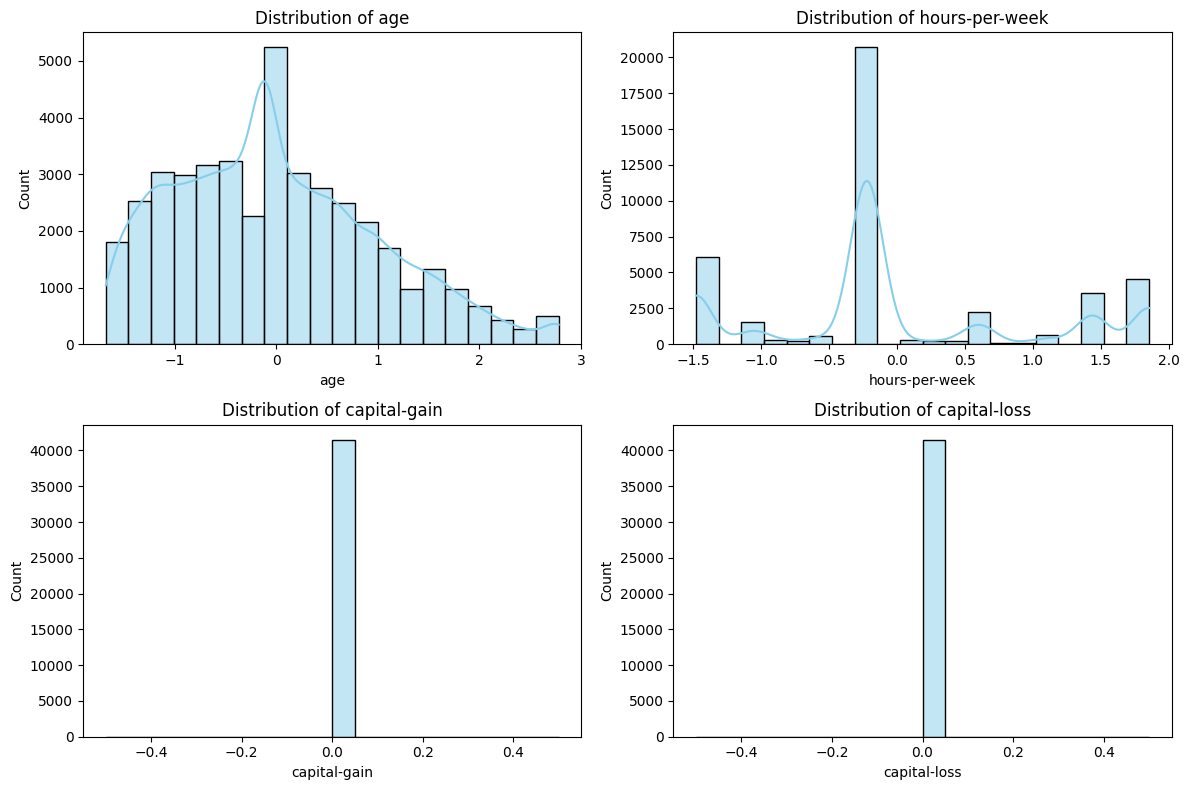

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Continuous numerical columns
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

# Plot histograms for numerical columns
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

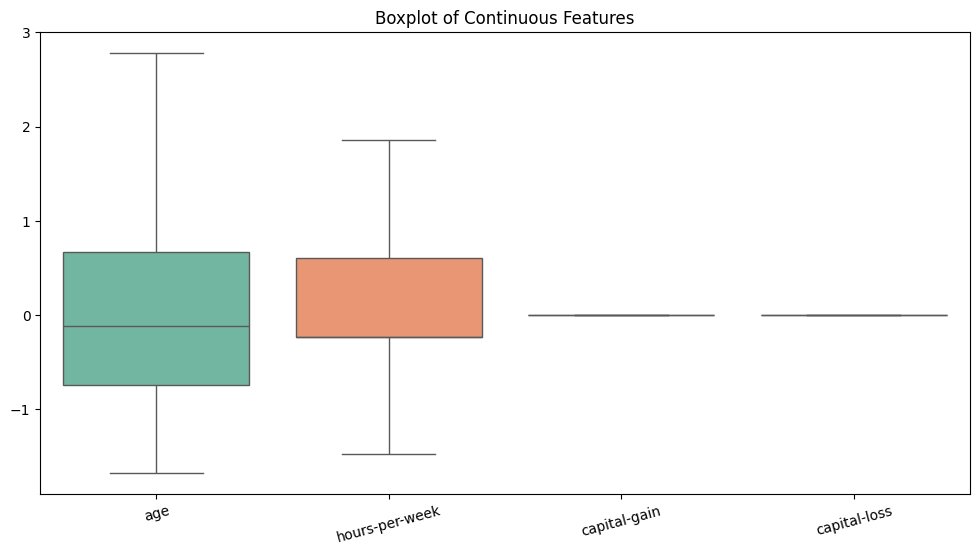

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[num_cols], palette='Set2')
plt.title('Boxplot of Continuous Features')
plt.xticks(rotation=15)
plt.show()

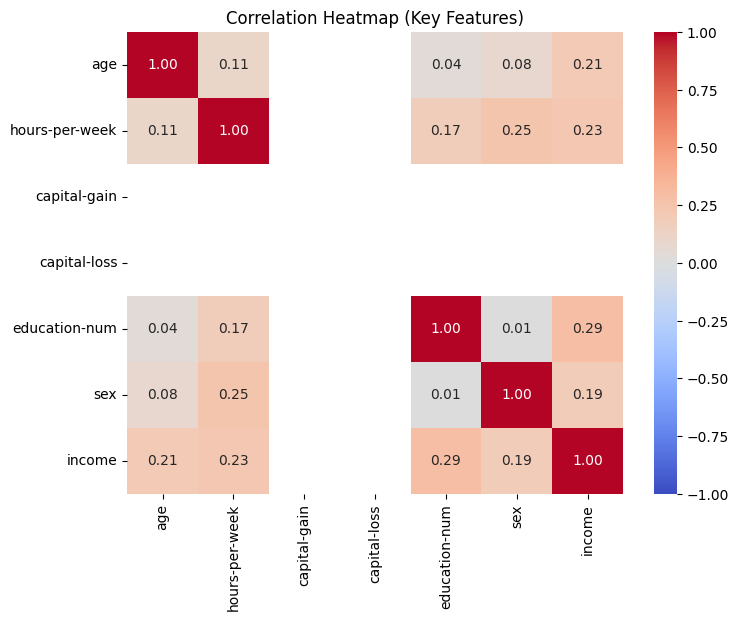

Top 10 Strongest Feature Correlations:
race_White                         race_Black                           0.792397
marital-status_Married-civ-spouse  marital-status_Never-married         0.644946
                                   relationship_Not-in-family           0.550017
age                                marital-status_Never-married         0.517310
workclass_Self-emp-not-inc         workclass_Private                    0.506164
marital-status_Never-married       relationship_Own-child               0.497771
workclass_Private                  workclass_Local-gov                  0.452230
sex                                marital-status_Married-civ-spouse    0.434737
race_White                         race_Asian-Pac-Islander              0.434367
occupation_Prof-specialty          education-num                        0.424604
dtype: float64


In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[['age', 'hours-per-week', 'capital-gain', 'capital-loss', 'education-num', 'sex', 'income']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Key Features)')
plt.show()

corr_matrix = data.corr().abs()
np.fill_diagonal(corr_matrix.values, 0)
top_corrs = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates().head(10)

print("Top 10 Strongest Feature Correlations:")
print(top_corrs)

Explained Variance Ratio: [9.99999999e-01 1.52394044e-10]
Total Variance Retained: 100.00%


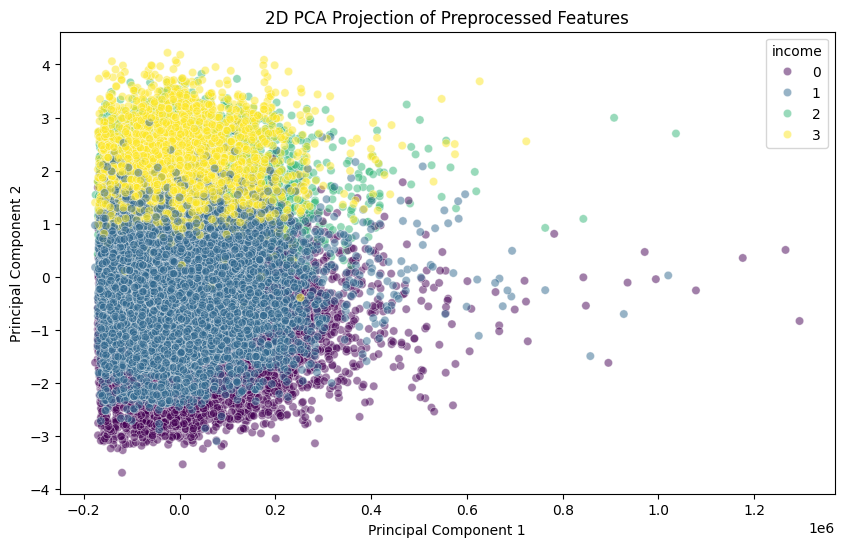

In [20]:
from sklearn.decomposition import PCA

# Fit 2D PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Print Explained Variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Plot PCA Results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=data['income'], alpha=0.5, palette='viridis')
plt.title('2D PCA Projection of Preprocessed Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

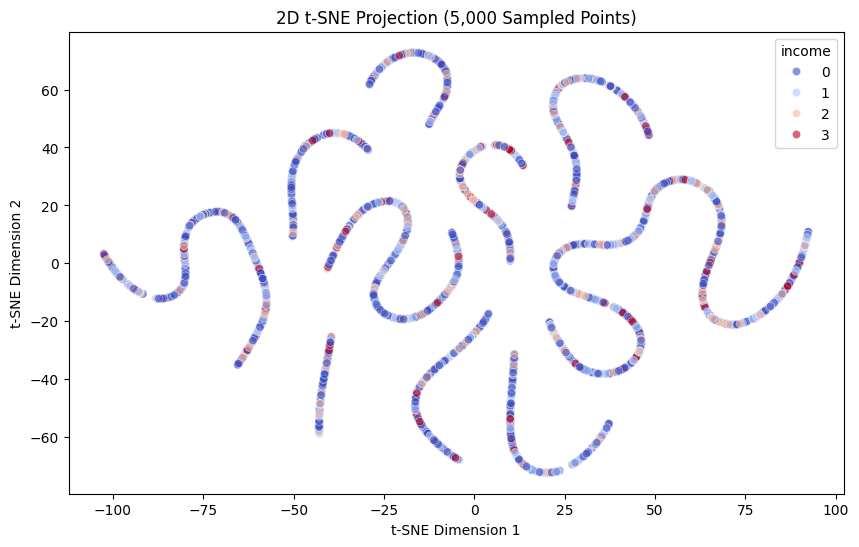

In [21]:
from sklearn.manifold import TSNE

# Sample 5,000 rows for fast execution
sample_data = data.sample(n=5000, random_state=42)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
data_tsne = tsne.fit_transform(sample_data)

# Plot t-SNE Results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_tsne[:, 0], y=data_tsne[:, 1], hue=sample_data['income'], alpha=0.6, palette='coolwarm')
plt.title('2D t-SNE Projection (5,000 Sampled Points)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [22]:
X=data.drop("income",axis=1)

In [23]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,
                random_state=42,
                n_init=10
  )
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)



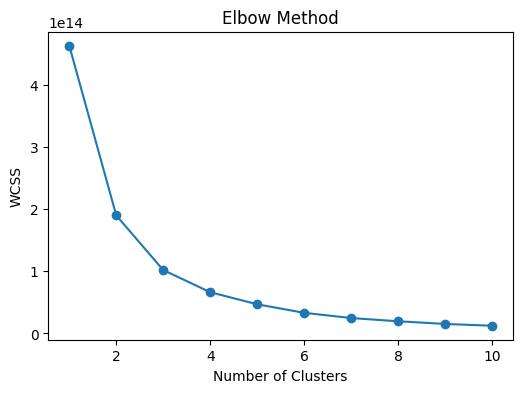

In [24]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [25]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.5885
K = 3, Silhouette Score = 0.5573
K = 4, Silhouette Score = 0.5644
K = 5, Silhouette Score = 0.5429
K = 6, Silhouette Score = 0.5521
K = 7, Silhouette Score = 0.5552
K = 8, Silhouette Score = 0.5438
K = 9, Silhouette Score = 0.5465
K = 10, Silhouette Score = 0.5470


In [40]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

In [41]:
data['kmeans_cluster']=clusters

In [42]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.5572752202082795


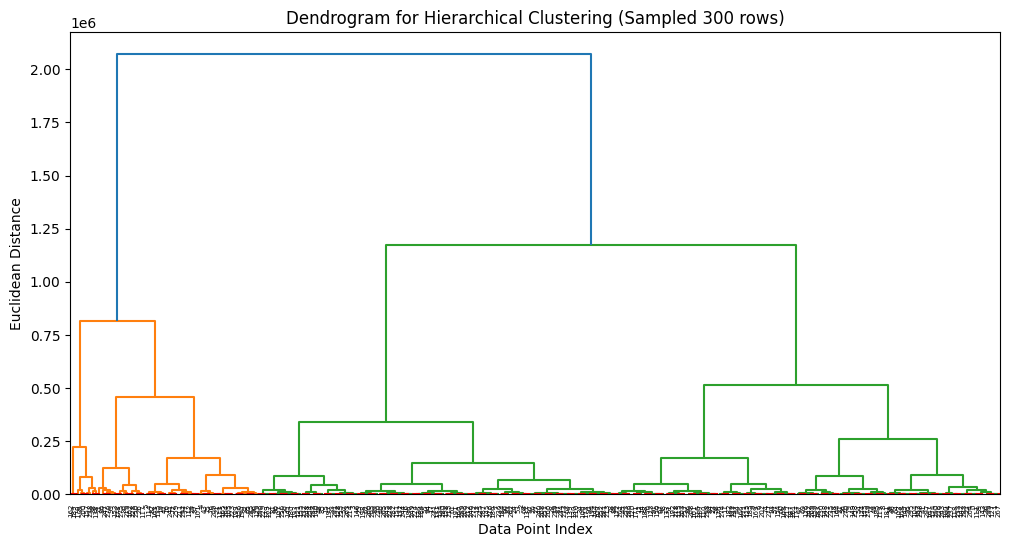

In [43]:
#agglo clustering
data_dendro = data[:300]

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(data_dendro, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering (Sampled 300 rows)')
plt.xlabel('Data Point Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=15, color='r', linestyle='--')
plt.show()

In [44]:
data_agg = data[:5000]
agg_clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
agg_labels = agg_clustering.fit_predict(data_agg)
agg_silhouette = silhouette_score(data_agg, agg_labels)
print(f"Agglo Clustering Silhouette Score (k=3): {agg_silhouette:.4f}")

Agglo Clustering Silhouette Score (k=3): 0.5520


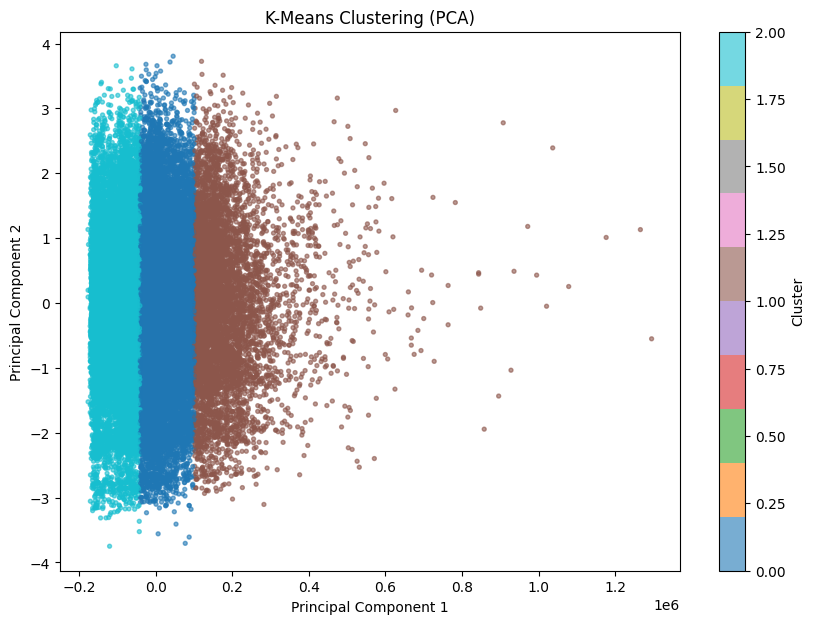

In [46]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='tab10',
    s=8,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (PCA)")
plt.colorbar(label="Cluster")

plt.show()

In [48]:

cluster_profiles = df_summary.groupby('Cluster')[
    ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex']
].mean()

cluster_profiles['Size'] = df_summary['Cluster'].value_counts()

print("Cluster Profiles (Mean Values):")
display(cluster_profiles)

Cluster Profiles (Mean Values):


,age,education-num,hours-per-week,capital-gain,capital-loss,sex,Size
Cluster,,,,,,,
0,-0.005718,-0.009572,-0.008577,0.0,0.0,0.674474,20152
1,-0.152539,-0.047406,-0.023640,0.0,0.0,0.706734,6148
2,0.069261,0.031856,0.020927,0.0,0.0,0.664496,15204


* cluster 0 : young- need upskilling financial aid
* cluster 1 : working class - upskilling , tax reforms
* cluster 2 : high earning and education - tax reforms, upskilling

In [49]:
recommendations = pd.DataFrame({
    'Cluster': ['Cluster 0', 'Cluster 1', 'Cluster 2'],
    'Demographic Profile': ['Younger / Low Education / Part-Time', 'Mid-Career / Standard Hours', 'High Education / High Capital Gain'],
    'Financial Aid Policy': ['Tuition Subsidies & Training Stipends', 'Childcare & Family Allowances', 'N/A'],
    'Tax Reform Policy': ['Low-Income Earned Income Tax Credit', 'Middle-Class Income Tax Offsets', 'Capital Gains & Investment Tax Reform'],
    'Upskilling Focus': ['Vocational & Entry-Level Tech Skills', 'Mid-Career Industry Certifications', 'Executive & Specialized Leadership']
})

display(recommendations)

,Cluster,Demographic Profile,Financial Aid Policy,Tax Reform Policy,Upskilling Focus
0,Cluster 0,Younger / Low Education / Part-Time,Tuition Subsidies & Training Stipends,Low-Income Earned Income Tax Credit,Vocational & Entry-Level Tech Skills
1,Cluster 1,Mid-Career / Standard Hours,Childcare & Family Allowances,Middle-Class Income Tax Offsets,Mid-Career Industry Certifications
2,Cluster 2,High Education / High Capital Gain,N/A,Capital Gains & Investment Tax Reform,Executive & Specialized Leadership
